# 07 — Model Error Analysis

## Understanding Where the Early-Warning Model Fails

This final notebook examines where the 1-hour Random Forest model makes mistakes and what those errors mean operationally.

The analysis focuses on:

- false positives and false negatives,
- operating conditions associated with errors,
- differences across system groups,
- the effect of changing the classification threshold,
- and model confidence when predictions are wrong.

The 1-hour model is used because it provides the strongest overall early-warning performance.

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option("display.max_columns", None)

df = pd.read_csv(
    "../data_processed/ml_ready_energy_data.csv",
    parse_dates=["window_start_utc"]
)

print("Dataset shape:", df.shape)

Dataset shape: (993411, 17)


## 1. What Types of Prediction Errors Does the Model Make?

For an operational early-warning system, not all prediction errors have the same consequence.

A **false negative** represents a high-demand observation that is not detected by the model, while a **false positive** represents a warning when high demand does not occur.

Because the main objective is to identify upcoming high-demand events before they occur, particular attention is given to false negatives and recall.

In [3]:
split_time = pd.Timestamp("2025-11-08 20:15:00")

test_df = df[
    df["window_start_utc"] >= split_time
].copy()

numeric_features = [
    "Demand_kW",
    "demand_15m_ago",
    "demand_30m_ago",
    "demand_45m_ago",
    "demand_60m_ago",
    "change_15m",
    "change_60m",
    "rolling_mean_1h",
    "rolling_std_1h",
    "demand_threshold_ratio",
    "hour",
    "day_of_week",
    "is_weekend"
]

categorical_features = [
    "asset_type"
]

features = numeric_features + categorical_features

X_test = test_df[features]
y_test = test_df["extreme_1h_ahead"]

rf_pipeline = joblib.load(
    "../data_processed/rf_model_1h.joblib"
)

y_pred = rf_pipeline.predict(X_test)

y_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Test rows:", len(test_df))
print("Predictions:", len(y_pred))

Test rows: 185929
Predictions: 185929


In [4]:
error_analysis = test_df[
    [
        "window_start_utc",
        "AssetId",
        "asset_type",
        "Demand_kW",
        "change_15m",
        "change_60m",
        "rolling_mean_1h",
        "rolling_std_1h",
        "demand_threshold_ratio",
        "extreme_1h_ahead"
    ]
].copy()

error_analysis["y_pred"] = y_pred
error_analysis["y_prob"] = y_prob

conditions = [
    (error_analysis["extreme_1h_ahead"] == 0) &
    (error_analysis["y_pred"] == 0),

    (error_analysis["extreme_1h_ahead"] == 0) &
    (error_analysis["y_pred"] == 1),

    (error_analysis["extreme_1h_ahead"] == 1) &
    (error_analysis["y_pred"] == 0),

    (error_analysis["extreme_1h_ahead"] == 1) &
    (error_analysis["y_pred"] == 1)
]

labels = [
    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
]

error_analysis["prediction_result"] = np.select(
    conditions,
    labels,
    default="Unknown"
)

error_counts = (
    error_analysis["prediction_result"]
    .value_counts()
)

print(error_counts)

print("\nPercent of all test observations:")

print(
    (error_counts / len(error_analysis) * 100)
    .round(2)
)

prediction_result
True Negative     141800
True Positive      27169
False Positive     14914
False Negative      2046
Name: count, dtype: int64

Percent of all test observations:
prediction_result
True Negative     76.27
True Positive     14.61
False Positive     8.02
False Negative     1.10
Name: count, dtype: float64


## 2. How Do False Positives and False Negatives Differ?

False positives and false negatives represent different operational risks.

- **False positives** may create unnecessary warnings and contribute to alert fatigue.
- **False negatives** are particularly important because they represent high-demand observations that occur without being detected in advance.

This section compares the operating conditions associated with correct predictions and prediction errors.

In [5]:
error_comparison = (
    error_analysis
    .groupby("prediction_result")
    .agg(
        Observations=("extreme_1h_ahead", "count"),
        Median_Demand_kW=("Demand_kW", "median"),
        Median_15m_Change=("change_15m", "median"),
        Median_60m_Change=("change_60m", "median"),
        Median_Threshold_Ratio=("demand_threshold_ratio", "median"),
        Median_Rolling_Std=("rolling_std_1h", "median"),
        Median_Predicted_Probability=("y_prob", "median")
    )
    .round(3)
)

error_comparison

,Observations,Median_Demand_kW,Median_15m_Change,Median_60m_Change,Median_Threshold_Ratio,Median_Rolling_Std,Median_Predicted_Probability
prediction_result,,,,,,,
False Negative,2046,2.551,-0.0,-0.0,0.535,0.191,0.317
False Positive,14914,7.895,0.0,0.0,0.991,0.852,0.728
True Negative,141800,0.192,0.0,0.0,0.106,0.002,0.068
True Positive,27169,4.740,0.0,0.0,1.242,0.245,0.883


## 3. Where Are Prediction Errors Concentrated?

Model performance may vary across different operational systems.

This section examines false-negative and false-positive rates by system type to identify systems where the early-warning model is less reliable and where additional monitoring, data, or model customization may be beneficial.

In [6]:
system_errors = (
    error_analysis
    .groupby("asset_type")
    .agg(
        Observations=("prediction_result", "size"),
        Actual_High_Demand=("extreme_1h_ahead", "sum"),
        Predicted_High_Demand=("y_pred", "sum"),
        False_Negatives=(
            "prediction_result",
            lambda x: (x == "False Negative").sum()
        ),
        False_Positives=(
            "prediction_result",
            lambda x: (x == "False Positive").sum()
        ),
        True_Positives=(
            "prediction_result",
            lambda x: (x == "True Positive").sum()
        )
    )
    .reset_index()
)

# Recall within each system
system_errors["Recall_Pct"] = (
    system_errors["True_Positives"] /
    system_errors["Actual_High_Demand"] * 100
)

# False-positive rate:
# FP / all observations that were actually normal
system_errors["False_Positive_Rate_Pct"] = (
    system_errors["False_Positives"] /
    (
        system_errors["Observations"] -
        system_errors["Actual_High_Demand"]
    ) * 100
)

system_errors = system_errors.sort_values(
    "Recall_Pct"
)

system_errors.round(2)

,asset_type,Observations,Actual_High_Demand,Predicted_High_Demand,False_Negatives,False_Positives,True_Positives,Recall_Pct,False_Positive_Rate_Pct
8,Press_Drive,15297,828,1820,175,1167,653,78.86,8.07
12,ProcessMixing,20396,1219,2873,176,1830,1043,85.56,9.54
11,Press_Main,40792,4417,7106,547,3236,3870,87.62,8.90
6,HVAC_AirExtraction,10198,496,755,50,309,446,89.92,3.18
10,Press_IntegratedAutomationCell,3931,537,1081,47,591,490,91.25,17.41
5,HVAC_AHU,14478,1643,2232,132,721,1511,91.97,5.62
9,Press_Heating,5099,1684,2183,131,630,1553,92.22,18.45
1,CompressedAir,10198,952,1582,70,700,882,92.65,7.57
13,Utilities,24748,4861,6404,346,1889,4515,92.88,9.50
3,Electrical_GridImport,5099,1538,1863,84,409,1454,94.54,11.49


In [7]:
def simplify_system_group(asset_type):
    
    if asset_type.startswith("Press") or asset_type == "ProcessMixing":
        return "Production Systems"
    
    elif asset_type.startswith("Automation"):
        return "Automation Systems"
    
    elif asset_type.startswith("HVAC"):
        return "Building & Climate Systems"
    
    elif (
        asset_type.startswith("Electrical")
        or asset_type == "Utilities"
        or asset_type == "CompressedAir"
    ):
        return "Electrical & Utility Systems"
    
    else:
        return "Other Systems"


error_analysis["system_group"] = (
    error_analysis["asset_type"]
    .apply(simplify_system_group)
)

group_errors = (
    error_analysis
    .groupby("system_group")
    .agg(
        Observations=("prediction_result", "size"),
        Actual_High_Demand=("extreme_1h_ahead", "sum"),
        False_Negatives=(
            "prediction_result",
            lambda x: (x == "False Negative").sum()
        ),
        False_Positives=(
            "prediction_result",
            lambda x: (x == "False Positive").sum()
        ),
        True_Positives=(
            "prediction_result",
            lambda x: (x == "True Positive").sum()
        )
    )
    .reset_index()
)

group_errors["Recall_Pct"] = (
    group_errors["True_Positives"] /
    group_errors["Actual_High_Demand"] * 100
)

group_errors["False_Positive_Rate_Pct"] = (
    group_errors["False_Positives"] /
    (
        group_errors["Observations"] -
        group_errors["Actual_High_Demand"]
    ) * 100
)

group_errors = group_errors.sort_values("Recall_Pct")

group_errors.round(2)

,system_group,Observations,Actual_High_Demand,False_Negatives,False_Positives,True_Positives,Recall_Pct,False_Positive_Rate_Pct
3,Production Systems,85515,8685,1076,7454,7609,87.61,9.70
2,Electrical & Utility Systems,60441,12655,688,4807,11967,94.56,10.06
1,Building & Climate Systems,34874,7610,278,2478,7332,96.35,9.09
0,Automation Systems,5099,265,4,175,261,98.49,3.62


## 4. How Does the Decision Threshold Affect Recall and False Alarms?

The default classification threshold of 0.50 is not necessarily the optimal operating point for an early-warning system.

Lowering the threshold can increase recall and detect more upcoming high-demand observations, but it may also generate more false alarms. Raising the threshold has the opposite effect.

This section evaluates the trade-off between recall, precision, F1-score, and false-positive rate across different probability thresholds.

In [8]:
threshold_results = []

for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    
    pred_threshold = (
        y_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        pred_threshold
    ).ravel()

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            pred_threshold
        ),
        "F1": f1_score(
            y_test,
            pred_threshold
        ),
        "False_Positive_Rate": fp / (fp + tn),
        "False_Negatives": fn,
        "False_Positives": fp
    })

threshold_comparison = pd.DataFrame(
    threshold_results
)

threshold_comparison[
    [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "False_Positive_Rate",
        "False_Negatives",
        "False_Positives"
    ]
].round(3)

,Threshold,Precision,Recall,F1,False_Positive_Rate,False_Negatives,False_Positives
0,0.3,0.522,0.968,0.678,0.165,940,25897
1,0.4,0.585,0.951,0.724,0.126,1422,19748
2,0.5,0.646,0.930,0.762,0.095,2046,14914
3,0.6,0.698,0.897,0.785,0.072,3011,11336
4,0.7,0.746,0.835,0.788,0.053,4821,8287


## 5. How Confident Is the Model When It Makes Errors?

Prediction errors are not equally concerning.

An error close to the decision threshold indicates model uncertainty, while a highly confident incorrect prediction may indicate operating conditions that the model does not represent well.

This section examines the predicted probabilities associated with false positives and false negatives.

In [9]:
confidence_analysis = (
    error_analysis
    .groupby("prediction_result")["y_prob"]
    .agg(
        Count="count",
        Median="median",
        Mean="mean",
        Q25=lambda x: x.quantile(0.25),
        Q75=lambda x: x.quantile(0.75)
    )
    .round(3)
)

confidence_analysis

,Count,Median,Mean,Q25,Q75
prediction_result,,,,,
False Negative,2046,0.317,0.306,0.206,0.420
False Positive,14914,0.728,0.729,0.605,0.854
True Negative,141800,0.068,0.107,0.022,0.158
True Positive,27169,0.883,0.852,0.795,0.926


In [10]:
high_confidence_fp = error_analysis[
    (error_analysis["prediction_result"] == "False Positive") &
    (error_analysis["y_prob"] >= 0.80)
]

high_confidence_fn = error_analysis[
    (error_analysis["prediction_result"] == "False Negative") &
    (error_analysis["y_prob"] <= 0.20)
]

print(
    "High-confidence false positives:",
    len(high_confidence_fp)
)

print(
    "High-confidence false negatives:",
    len(high_confidence_fn)
)

print(
    "\nHigh-confidence FP as % of all false positives:",
    round(
        len(high_confidence_fp) /
        (error_analysis["prediction_result"] == "False Positive").sum()
        * 100,
        2
    ),
    "%"
)

print(
    "High-confidence FN as % of all false negatives:",
    round(
        len(high_confidence_fn) /
        (error_analysis["prediction_result"] == "False Negative").sum()
        * 100,
        2
    ),
    "%"
)

High-confidence false positives: 5479
High-confidence false negatives: 472

High-confidence FP as % of all false positives: 36.74 %
High-confidence FN as % of all false negatives: 23.07 %


## 6. Summary and Model Limitations

The error analysis shows that the 1-hour Random Forest performs strongly overall, but its mistakes are not random.

At the default 0.50 classification threshold, the model detects about 93% of high-demand observations. False negatives tend to occur when current demand is still relatively far below the asset-specific high-demand threshold, while many false positives occur when demand is already close to the threshold.

Performance also differs across operational system groups. Production Systems show the lowest recall among the main groups, while Building & Climate and Automation Systems achieve higher recall.

Changing the classification threshold creates a clear trade-off. Lower thresholds detect more high-demand observations but generate more false alarms, while higher thresholds reduce false alarms at the cost of missed events.

Some errors are also made with relatively high model confidence, which means threshold adjustment alone cannot eliminate all prediction mistakes.

The main limitation is that the model relies primarily on historical electricity-demand behavior. Additional operational information such as production schedules, machine states or planned equipment starts could help explain and predict the more difficult events.

Overall, the model is best used as a decision-support system rather than an automatic control mechanism. Its probability scores and warning thresholds can be adapted to operational priorities and the relative cost of missed events versus unnecessary alerts.

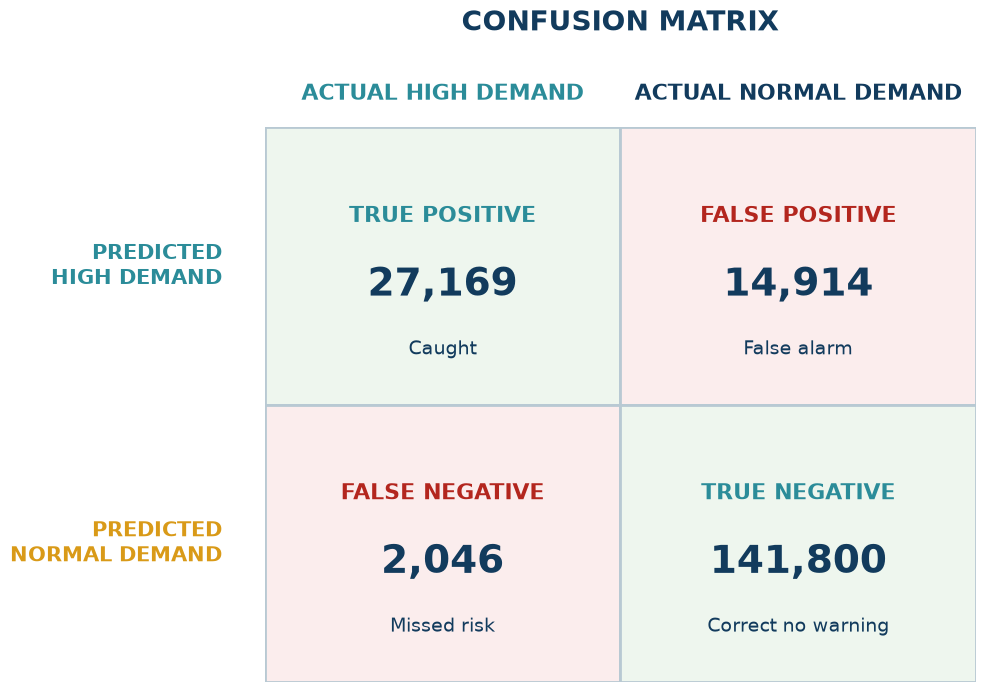

In [11]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --------------------------------------------------
# VALUES FROM NOTEBOOK 7 - CELL 4
# --------------------------------------------------

tp = 27169
fp = 14914
fn = 2046
tn = 141800

# --------------------------------------------------
# PRESENTATION COLORS
# --------------------------------------------------

navy = "#123B5D"
teal = "#2B8C99"
gold = "#D99A18"

green_fill = "#EEF6EE"
red_fill = "#FBEDED"
border = "#B8C9D3"

# --------------------------------------------------
# FIGURE
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 7))

fig.patch.set_alpha(0)
ax.set_facecolor("white")

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.axis("off")

# --------------------------------------------------
# CELLS
# --------------------------------------------------

cells = [
    (0, 1, green_fill, "TRUE POSITIVE", tp, "Caught"),
    (1, 1, red_fill, "FALSE POSITIVE", fp, "False alarm"),
    (0, 0, red_fill, "FALSE NEGATIVE", fn, "Missed risk"),
    (1, 0, green_fill, "TRUE NEGATIVE", tn, "Correct no warning"),
]

for x, y, fill, title, value, note in cells:

    rect = Rectangle(
        (x, y),
        1,
        1,
        facecolor=fill,
        edgecolor=border,
        linewidth=2
    )

    ax.add_patch(rect)

    title_color = (
        teal if "TRUE" in title
        else "#B3261E"
    )

    ax.text(
        x + 0.5,
        y + 0.68,
        title,
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        color=title_color
    )

    ax.text(
        x + 0.5,
        y + 0.43,
        f"{value:,}",
        ha="center",
        va="center",
        fontsize=28,
        fontweight="bold",
        color=navy
    )

    ax.text(
        x + 0.5,
        y + 0.20,
        note,
        ha="center",
        va="center",
        fontsize=14,
        color=navy
    )

# --------------------------------------------------
# COLUMN LABELS
# --------------------------------------------------

ax.text(
    0.5,
    2.10,
    "ACTUAL HIGH DEMAND",
    ha="center",
    fontsize=16,
    fontweight="bold",
    color=teal
)

ax.text(
    1.5,
    2.10,
    "ACTUAL NORMAL DEMAND",
    ha="center",
    fontsize=16,
    fontweight="bold",
    color=navy
)

# --------------------------------------------------
# ROW LABELS
# --------------------------------------------------

ax.text(
    -0.12,
    1.5,
    "PREDICTED\nHIGH DEMAND",
    ha="right",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=teal
)

ax.text(
    -0.12,
    0.5,
    "PREDICTED\nNORMAL DEMAND",
    ha="right",
    va="center",
    fontsize=15,
    fontweight="bold",
    color=gold
)

# --------------------------------------------------
# TITLE
# --------------------------------------------------

ax.text(
    1,
    2.35,
    "CONFUSION MATRIX",
    ha="center",
    fontsize=20,
    fontweight="bold",
    color=navy
)

# --------------------------------------------------
# SAVE
# --------------------------------------------------

plt.tight_layout()

plt.savefig(
    "../presentation/confusion_matrix_light.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()